# DriveGuard (Single Camera): Temporal Model
**SingleViewDriveTransformer**: TemporalEncoder (CLS token, 4L Pre-LN) + Linear classifier

Camera: `a_column_co_driver`  
Input: `ViT_Features/{split}/{class}/a_column_co_driver_*.npy` — shape `(16, 1152)`  
Output: 3-class prediction (Safe / Drink / Phone)


In [3]:
# Cell 1
import os, gc, shutil, json, contextlib
import numpy as np
import torch
import subprocess

subprocess.run(['pip', 'install', '-q', 'torchmetrics', 'seaborn', 'scikit-learn'], check=True)

from google.colab import drive
try:
    drive.mount('/content/drive')
except Exception:
    print('Drive already mounted or mount failed — continuing.')

DRIVE_BASE    = '/content/drive/MyDrive/DriveGuard'
FEATURES_ROOT = '/content/drive/MyDrive/DriveGuard/ViT_Features'

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
PIN_MEMORY = (device == 'cuda')
print(f'Device: {device}')
if device == 'cuda':
    print(f'  GPU:  {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark        = True
    torch.set_float32_matmul_precision('high')

if device == 'cuda' and torch.cuda.is_bf16_supported():
    _AMP_DTYPE = torch.bfloat16
    print('  AMP:  bfloat16')
elif device == 'cuda':
    _AMP_DTYPE = torch.float16
    print('  AMP:  float16')
else:
    _AMP_DTYPE = None
    print('  AMP:  disabled (CPU)')

def autocast():
    if _AMP_DTYPE is not None:
        return torch.amp.autocast(device_type='cuda', dtype=_AMP_DTYPE)
    return contextlib.nullcontext()

def cuda_cleanup():
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
  GPU:  NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB
  AMP:  bfloat16


In [2]:
# Cell 2
from tqdm.auto import tqdm

LOCAL_FEATURES = '/content/features'

if not os.path.isdir(FEATURES_ROOT):
    raise RuntimeError(
        f'Drive path not found: {FEATURES_ROOT}\n'
        f'Re-run Cell 1 or: from google.colab import drive; drive.mount("/content/drive", force_remount=True)'
    )

if os.path.exists(LOCAL_FEATURES):
    print(f'Local features already exist at {LOCAL_FEATURES} — skipping copy.')
else:
    total_files = sum(len(files) for _, _, files in os.walk(FEATURES_ROOT))
    print(f'Copying {FEATURES_ROOT} -> {LOCAL_FEATURES}  ({total_files:,} files) ...')
    shutil.copytree(FEATURES_ROOT, LOCAL_FEATURES)
    copied = sum(len(files) for _, _, files in os.walk(LOCAL_FEATURES))
    print(f'Done. {copied:,} files copied.')

FEATURES_ROOT = LOCAL_FEATURES
print(f'FEATURES_ROOT -> {FEATURES_ROOT}')


Copying /content/drive/MyDrive/DriveGuard/ViT_Features -> /content/features  (17,019 files) ...
Done. 17,019 files copied.
FEATURES_ROOT -> /content/features


In [4]:
# Cell 3
CFG = {
    'camera'           : 'a_column_co_driver',
    'classes'          : ['Drink', 'Phone', 'Safe'],
    'num_frames'       : 16,
    'input_dim'        : 1152,
    'num_classes'      : 3,
    'features_root'    : FEATURES_ROOT,
    'hidden_dim'       : 768,
    'num_heads'        : 8,
    'num_layers'       : 4,
    'dim_feedforward'  : 2048,
    'dropout'          : 0.3,
    'noise_std'        : 0.075,
    'batch_size'       : 32,
    'label_smoothing'  : 0.05,
    'num_epochs_warmup': 5,
    'num_epochs_full'  : 40,
    'patience'         : 10,
    'grad_clip'        : 1.0,
    'lr_warmup'        : 1e-3,
    'lr_encoder'       : 3e-4,
    'lr_head'          : 5e-4,
    'weight_decay'     : 0.05,
    'checkpoint_name'  : 'temporal_head_model.pth',
}

print('CFG loaded:')
for k, v in CFG.items():
    print(f'  {k:20s}: {v}', flush=True)


CFG loaded:
  camera              : a_column_co_driver
  classes             : ['Drink', 'Phone', 'Safe']
  num_frames          : 16
  input_dim           : 1152
  num_classes         : 3
  features_root       : /content/drive/MyDrive/DriveGuard/ViT_Features
  hidden_dim          : 768
  num_heads           : 8
  num_layers          : 4
  dim_feedforward     : 2048
  dropout             : 0.3
  noise_std           : 0.075
  batch_size          : 32
  label_smoothing     : 0.05
  num_epochs_warmup   : 5
  num_epochs_full     : 40
  patience            : 10
  grad_clip           : 1.0
  lr_warmup           : 0.001
  lr_encoder          : 0.0003
  lr_head             : 0.0005
  weight_decay        : 0.05
  checkpoint_name     : temporal_head_model.pth


In [5]:
# Cell 4
from collections import Counter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


class SingleCamDataset(Dataset):
    def __init__(self, features_root: str, split: str, cfg: dict):
        self.cfg     = cfg
        self.samples = []
        self.labels  = []

        cam_prefix = cfg['camera']

        for label_idx, cls in enumerate(cfg['classes']):
            cls_dir = os.path.join(features_root, split, cls)
            if not os.path.isdir(cls_dir):
                print(f'  [WARNING] Missing directory: {cls_dir}')
                continue
            for fname in sorted(f for f in os.listdir(cls_dir)
                                 if f.endswith('.npy') and f.startswith(cam_prefix)):
                self.samples.append((label_idx, os.path.join(cls_dir, fname)))
                self.labels.append(label_idx)

        counts = Counter(self.labels)
        print(f'[SingleCamDataset | {split}]  camera={cam_prefix}')
        for cls_i, cls in enumerate(cfg['classes']):
            print(f'  {cls:8s}: {counts.get(cls_i, 0):4d} sequences')
        print(f'  TOTAL   : {len(self.samples):4d}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        label, path = self.samples[idx]
        T    = self.cfg['num_frames']
        D    = self.cfg['input_dim']
        feat = np.load(path).astype(np.float32)
        if feat.shape[0] < T:
            feat = np.concatenate([feat, np.zeros((T - feat.shape[0], D), dtype=np.float32)])
        return torch.from_numpy(feat[:T]), torch.tensor(label, dtype=torch.long)


In [6]:
# Cell 5
NUM_WORKERS = 2

train_ds = SingleCamDataset(CFG['features_root'], 'train', CFG)
val_ds   = SingleCamDataset(CFG['features_root'], 'val',   CFG)
test_ds  = SingleCamDataset(CFG['features_root'], 'test',  CFG)

class_counts = Counter(train_ds.labels)
sample_wts   = torch.tensor(
    [1.0 / class_counts[l] for l in train_ds.labels], dtype=torch.float32
)
sampler = WeightedRandomSampler(sample_wts, num_samples=len(sample_wts), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'], sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0)
)
val_loader = DataLoader(
    val_ds, batch_size=CFG['batch_size'], shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0)
)
test_loader = DataLoader(
    test_ds, batch_size=CFG['batch_size'], shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0)
)

total_train   = sum(class_counts.values())
class_weights = torch.tensor(
    [total_train / (CFG['num_classes'] * class_counts[i]) for i in range(CFG['num_classes'])],
    dtype=torch.float32
).to(device)

print(f'DataLoaders ready  (num_workers={NUM_WORKERS})')
print(f'  Train: {len(train_ds):,} sequences, {len(train_loader)} batches')
print(f'  Val:   {len(val_ds):,} sequences')
print(f'  Test:  {len(test_ds):,} sequences')
print(f'  Class weights (Drink/Phone/Safe): {[f"{w:.3f}" for w in class_weights.tolist()]}')


[SingleCamDataset | train]  camera=a_column_co_driver
  Drink   :  760 sequences
  Phone   :  506 sequences
  Safe    :  757 sequences
  TOTAL   : 2023
[SingleCamDataset | val]  camera=a_column_co_driver
  Drink   :  209 sequences
  Phone   :  125 sequences
  Safe    :  209 sequences
  TOTAL   :  543
[SingleCamDataset | test]  camera=a_column_co_driver
  Drink   :  311 sequences
  Phone   :  148 sequences
  Safe    :  323 sequences
  TOTAL   :  782
DataLoaders ready  (num_workers=2)
  Train: 2,023 sequences, 64 batches
  Val:   543 sequences
  Test:  782 sequences
  Class weights (Drink/Phone/Safe): ['0.887', '1.333', '0.891']


In [7]:
# Cell 6
import torch.nn as nn


class TemporalEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D, H = cfg['input_dim'], cfg['hidden_dim']
        T    = cfg['num_frames']

        self.input_proj  = nn.Linear(D, H)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, H))
        self.pos_embed   = nn.Parameter(torch.zeros(1, T + 1, H))
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=H, nhead=cfg['num_heads'],
                dim_feedforward=cfg['dim_feedforward'],
                dropout=cfg['dropout'], batch_first=True, norm_first=True,
            ),
            num_layers=cfg['num_layers'],
        )
        self.norm = nn.LayerNorm(H)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)

    def forward(self, x):
        B   = x.size(0)
        x   = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1) + self.pos_embed
        return self.norm(self.transformer(x)[:, 0])


class SingleViewDriveTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder    = TemporalEncoder(cfg)
        self.dropout    = nn.Dropout(cfg['dropout'])
        self.classifier = nn.Linear(cfg['hidden_dim'], cfg['num_classes'])
        self.noise_std  = cfg['noise_std']

    def forward(self, x):
        if self.training and self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return self.classifier(self.dropout(self.encoder(x)))


model = SingleViewDriveTransformer(CFG).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'SingleViewDriveTransformer  {total_params:,} params ({total_params/1e6:.2f} M)  device={device}')
try:
    model = torch.compile(model)
    print('torch.compile: enabled')
except Exception as e:
    print(f'torch.compile: skipped ({e})')


SingleViewDriveTransformer  22,959,107 params (22.96 M)  device=cuda


/tmp/ipykernel_1140/3524892529.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


torch.compile: enabled


In [8]:
# Cell 7
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchmetrics.classification import MulticlassF1Score

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CFG['label_smoothing'])
f1_metric = MulticlassF1Score(num_classes=CFG['num_classes'], average='macro').to(device)

print(f"Criterion: WeightedCrossEntropy  label_smoothing={CFG['label_smoothing']}")
print(f"Class weights: {[f'{w:.3f}' for w in class_weights.tolist()]}")


Criterion: WeightedCrossEntropy  label_smoothing=0.05
Class weights: ['0.887', '1.333', '0.891']


In [9]:
# Cell 8
def train_epoch(model, loader, optimizer):
    model.train()
    f1_metric.reset()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in tqdm(loader, desc='Train', leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(x)
            loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        optimizer.step()
        preds = logits.detach().float().argmax(dim=1)
        total_loss += loss.item() * y.size(0)
        correct    += (preds == y).sum().item()
        n          += y.size(0)
        f1_metric.update(preds, y)
    return total_loss / n, correct / n, f1_metric.compute().item()


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    f1_metric.reset()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in tqdm(loader, desc='Eval ', leave=False):
        x, y = x.to(device), y.to(device)
        with autocast():
            logits = model(x)
            loss   = criterion(logits, y)
        preds = logits.float().argmax(dim=1)
        total_loss += loss.item() * y.size(0)
        correct    += (preds == y).sum().item()
        n          += y.size(0)
        f1_metric.update(preds, y)
    return total_loss / n, correct / n, f1_metric.compute().item()


print('Training utilities ready.')


Training utilities ready.


In [10]:
# Cell 9
ABLATION_WARMUP = 5
ABLATION_FULL   = 15

ABLATION_RUNS = [
    {'name': 'baseline',     'dropout': 0.30, 'noise_std': 0.075, 'phone_w': 1.0, 'focal': False, 'gamma': 0.0},
    {'name': 'phone_w_2.5',  'dropout': 0.30, 'noise_std': 0.075, 'phone_w': 2.5, 'focal': False, 'gamma': 0.0},
    {'name': 'phone_w_3.0',  'dropout': 0.30, 'noise_std': 0.075, 'phone_w': 3.0, 'focal': False, 'gamma': 0.0},
    {'name': 'dropout_0.45', 'dropout': 0.45, 'noise_std': 0.075, 'phone_w': 1.0, 'focal': False, 'gamma': 0.0},
    {'name': 'noise_0.12',   'dropout': 0.30, 'noise_std': 0.120, 'phone_w': 1.0, 'focal': False, 'gamma': 0.0},
    {'name': 'focal_gamma2', 'dropout': 0.30, 'noise_std': 0.075, 'phone_w': 1.0, 'focal': True,  'gamma': 2.0},
    {'name': 'combined',     'dropout': 0.45, 'noise_std': 0.120, 'phone_w': 2.5, 'focal': False, 'gamma': 0.0},
    {'name': 'phone_focused','dropout': 0.30, 'noise_std': 0.075, 'phone_w': 4.5, 'focal': True,  'gamma': 2.0},
]


class FocalLoss(nn.Module):
    def __init__(self, gamma, weight, label_smoothing):
        super().__init__()
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(weight=weight, reduction='none', label_smoothing=label_smoothing)

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def _build_criterion(run_cfg):
    cw = class_weights.clone()
    cw[1] = cw[1] * run_cfg['phone_w']
    cw = cw / cw.mean()
    if run_cfg['focal']:
        return FocalLoss(run_cfg['gamma'], cw, CFG['label_smoothing'])
    return nn.CrossEntropyLoss(weight=cw, label_smoothing=CFG['label_smoothing'])


from torchmetrics.classification import MulticlassF1Score as _F1
_f1_macro = _F1(num_classes=3, average='macro').to(device)
_f1_per   = _F1(num_classes=3, average=None).to(device)


def _run_ablation(run_cfg):
    name = run_cfg['name']
    print(f'{"="*60}  RUN: {name}', flush=True)

    mcfg = {**CFG, 'dropout': run_cfg['dropout'], 'noise_std': run_cfg['noise_std']}
    m    = SingleViewDriveTransformer(mcfg).to(device)
    try:
        m = torch.compile(m)
    except Exception:
        pass

    crit = _build_criterion(run_cfg)

    def _train(loader, opt):
        m.train()
        total, n = 0.0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            with autocast():
                loss = crit(m(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), CFG['grad_clip'])
            opt.step()
            total += loss.item() * y.size(0);  n += y.size(0)
        return total / n

    @torch.no_grad()
    def _eval(loader):
        m.eval();  _f1_macro.reset();  _f1_per.reset()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast():
                preds = m(x).float().argmax(dim=1)
            _f1_macro.update(preds, y);  _f1_per.update(preds, y)
        return _f1_macro.compute().item(), _f1_per.compute()

    orig = m._orig_mod if hasattr(m, '_orig_mod') else m
    for p in orig.encoder.parameters():
        p.requires_grad_(False)
    o1 = AdamW(orig.classifier.parameters(), lr=CFG['lr_warmup'], weight_decay=CFG['weight_decay'])
    s1 = CosineAnnealingLR(o1, T_max=ABLATION_WARMUP)
    for _ in range(ABLATION_WARMUP):
        _train(train_loader, o1);  s1.step()
    for p in orig.encoder.parameters():
        p.requires_grad_(True)

    o2 = AdamW([
        {'params': orig.encoder.parameters(),    'lr': CFG['lr_encoder']},
        {'params': orig.classifier.parameters(), 'lr': CFG['lr_head']},
    ], weight_decay=CFG['weight_decay'])
    s2 = CosineAnnealingLR(o2, T_max=ABLATION_FULL)

    best_macro, best_wts = 0.0, None
    for epoch in range(1, ABLATION_FULL + 1):
        tr_loss = _train(train_loader, o2)
        vl_macro, vl_per = _eval(val_loader)
        s2.step()
        marker = ''
        if vl_macro > best_macro:
            best_macro = vl_macro
            best_wts   = {k.replace('_orig_mod.', ''): v.cpu().clone()
                          for k, v in m.state_dict().items()}
            marker = ' <'
        print(f'  [{epoch:02d}/{ABLATION_FULL}] loss={tr_loss:.4f}'
              f'  val_macro={vl_macro:.4f}  Phone={vl_per[1]:.4f}{marker}', flush=True)

    m_clean = SingleViewDriveTransformer(mcfg).to(device)
    m_clean.load_state_dict(best_wts)
    m_clean.eval()
    _f1_macro.reset();  _f1_per.reset()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            with autocast():
                preds = m_clean(x).float().argmax(dim=1)
            _f1_macro.update(preds, y);  _f1_per.update(preds, y)
    final_macro = _f1_macro.compute().item()
    final_per   = _f1_per.compute()

    print(f'  BEST -> macro={final_macro:.4f}  '
          f'Phone={final_per[1]:.4f}  Drink={final_per[0]:.4f}  Safe={final_per[2]:.4f}', flush=True)
    cuda_cleanup()

    return {
        'name'        : name,
        'val_macro_f1': final_macro,
        'val_phone_f1': final_per[1].item(),
        'val_drink_f1': final_per[0].item(),
        'val_safe_f1' : final_per[2].item(),
        'best_wts'    : best_wts,
        'run_cfg'     : run_cfg,
    }


ablation_results = []
for run in ABLATION_RUNS:
    ablation_results.append(_run_ablation(run))

print('\nALL ABLATION RUNS COMPLETE', flush=True)


============================================================  RUN: baseline


/tmp/ipykernel_1140/3524892529.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  [01/15] loss=0.2064  val_macro=0.9404  Phone=0.9138 <
  [02/15] loss=0.2042  val_macro=0.9487  Phone=0.9277 <
  [03/15] loss=0.2008  val_macro=0.9449  Phone=0.9231
  [04/15] loss=0.2005  val_macro=0.9404  Phone=0.9138
  [05/15] loss=0.2018  val_macro=0.9404  Phone=0.9138
  [06/15] loss=0.1988  val_macro=0.9404  Phone=0.9138
  [07/15] loss=0.1983  val_macro=0.9449  Phone=0.9231
  [08/15] loss=0.1960  val_macro=0.9404  Phone=0.9138
  [09/15] loss=0.1991  val_macro=0.9532  Phone=0.9367 <
  [10/15] loss=0.1990  val_macro=0.9404  Phone=0.9138
  [11/15] loss=0.2032  val_macro=0.9404  Phone=0.9138
  [12/15] loss=0.1967  val_macro=0.9465  Phone=0.9231
  [13/15] loss=0.1998  val_macro=0.9472  Phone=0.9277
  [14/15] loss=0.1988  val_macro=0.9449  Phone=0.9231
  [15/15] loss=0.1943  val_macro=0.9449  Phone=0.9231


/tmp/ipykernel_1140/3524892529.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  BEST -> macro=0.9532  Phone=0.9367  Drink=0.9760  Safe=0.9469
============================================================  RUN: phone_w_2.5
  [01/15] loss=0.1831  val_macro=0.9666  Phone=0.9756 <
  [02/15] loss=0.1861  val_macro=0.9692  Phone=0.9839 <
  [03/15] loss=0.1790  val_macro=0.9634  Phone=0.9756
  [04/15] loss=0.1854  val_macro=0.9708  Phone=0.9839 <
  [05/15] loss=0.1855  val_macro=0.9708  Phone=0.9839 <
  [06/15] loss=0.1814  val_macro=0.9740  Phone=0.9839 <
  [07/15] loss=0.1781  val_macro=0.9708  Phone=0.9839
  [08/15] loss=0.1867  val_macro=0.9724  Phone=0.9839
  [09/15] loss=0.1759  val_macro=0.9708  Phone=0.9839
  [10/15] loss=0.1770  val_macro=0.9666  Phone=0.9756
  [11/15] loss=0.1811  val_macro=0.9708  Phone=0.9839
  [12/15] loss=0.1792  val_macro=0.9708  Phone=0.9839
  [13/15] loss=0.1814  val_macro=0.9708  Phone=0.9839
  [14/15] loss=0.1790  val_macro=0.9708  Phone=0.9839
  [15/15] loss=0.1769  val_macro=0.9708  Phone=0.9839
  BEST -> macro=0.9740  Phone=0.9839 

...

  BEST -> macro=0.9604  Phone=0.9544  Drink=0.9736  Safe=0.9533
============================================================  RUN: noise_0.12
  [01/15] loss=0.2043  val_macro=0.9448  Phone=0.9322 <
  [02/15] loss=0.2019  val_macro=0.9373  Phone=0.9138
  [03/15] loss=0.1992  val_macro=0.9485  Phone=0.9367 <
  [04/15] loss=0.1983  val_macro=0.9290  Phone=0.8996
  [05/15] loss=0.2011  val_macro=0.9396  Phone=0.9185
  [06/15] loss=0.2004  val_macro=0.9516  Phone=0.9367 <
  [07/15] loss=0.2023  val_macro=0.9554  Phone=0.9412 <
  [08/15] loss=0.2000  val_macro=0.9532  Phone=0.9367
  [09/15] loss=0.1974  val_macro=0.9560  Phone=0.9456 <
  [10/15] loss=0.1985  val_macro=0.9510  Phone=0.9322
  [11/15] loss=0.2031  val_macro=0.9554  Phone=0.9412
  [12/15] loss=0.1976  val_macro=0.9554  Phone=0.9412
  [13/15] loss=0.2006  val_macro=0.9554  Phone=0.9412
  [14/15] loss=0.1972  val_macro=0.9510  Phone=0.9322
  [15/15] loss=0.2007  val_macro=0.9510  Phone=0.9322


/tmp/ipykernel_1140/3524892529.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  BEST -> macro=0.9560  Phone=0.9456  Drink=0.9736  Safe=0.9488
============================================================  RUN: focal_gamma2
  [01/15] loss=0.0138  val_macro=0.9464  Phone=0.9231 <
  [02/15] loss=0.0109  val_macro=0.9431  Phone=0.9231
  [03/15] loss=0.0134  val_macro=0.9463  Phone=0.9231
  [04/15] loss=0.0136  val_macro=0.9510  Phone=0.9322 <
  [05/15] loss=0.0118  val_macro=0.9480  Phone=0.9231
  [06/15] loss=0.0117  val_macro=0.9480  Phone=0.9231
  [07/15] loss=0.0101  val_macro=0.9510  Phone=0.9322
  [08/15] loss=0.0106  val_macro=0.9620  Phone=0.9544 <
  [09/15] loss=0.0110  val_macro=0.9502  Phone=0.9277
  [10/15] loss=0.0098  val_macro=0.9598  Phone=0.9500
  [11/15] loss=0.0093  val_macro=0.9464  Phone=0.9231
  [12/15] loss=0.0107  val_macro=0.9547  Phone=0.9367
  [13/15] loss=0.0095  val_macro=0.9502  Phone=0.9277
  [14/15] loss=0.0105  val_macro=0.9502  Phone=0.9277
  [15/15] loss=0.0118  val_macro=0.9525  Phone=0.9322
  BEST -> macro=0.9620  Phone=0.9544  Dr

/tmp/ipykernel_1140/3524892529.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  BEST -> macro=0.9663  Phone=0.9630  Drink=0.9761  Safe=0.9600
============================================================  RUN: phone_focused
  [01/15] loss=0.0077  val_macro=0.9701  Phone=0.9672 <
  [02/15] loss=0.0079  val_macro=0.9686  Phone=0.9672
  [03/15] loss=0.0065  val_macro=0.9679  Phone=0.9630
  [04/15] loss=0.0066  val_macro=0.9685  Phone=0.9672
  [05/15] loss=0.0067  val_macro=0.9664  Phone=0.9630
  [06/15] loss=0.0071  val_macro=0.9766  Phone=0.9798 <
  [07/15] loss=0.0055  val_macro=0.9728  Phone=0.9760
  [08/15] loss=0.0056  val_macro=0.9734  Phone=0.9798
  [09/15] loss=0.0052  val_macro=0.9750  Phone=0.9798
  [10/15] loss=0.0051  val_macro=0.9750  Phone=0.9798
  [11/15] loss=0.0053  val_macro=0.9685  Phone=0.9672
  [12/15] loss=0.0049  val_macro=0.9685  Phone=0.9672
  [13/15] loss=0.0062  val_macro=0.9723  Phone=0.9714
  [14/15] loss=0.0058  val_macro=0.9707  Phone=0.9714
  [15/15] loss=0.0052  val_macro=0.9707  Phone=0.9714
  BEST -> macro=0.9766  Phone=0.9798  Dri

In [11]:
# Cell 10
actual_winner = max(ablation_results, key=lambda x: (x['val_phone_f1'], x['val_macro_f1']))
header = f"{'Run':<18}  {'Macro F1':>10}  {'Phone F1':>10}  {'Drink F1':>10}  {'Safe F1':>10}"

print(f"\n{'='*len(header)}")
print(header)
print(f"{'-'*len(header)}")
for r in sorted(ablation_results, key=lambda x: (-x['val_phone_f1'], -x['val_macro_f1'])):
    marker = '  <- WINNER' if r['name'] == actual_winner['name'] else ''
    print(f"{r['name']:18}  {r['val_macro_f1']:10.4f}  {r['val_phone_f1']:10.4f}  "
          f"{r['val_drink_f1']:10.4f}  {r['val_safe_f1']:10.4f}{marker}")
print(f"{'='*len(header)}\n")

winner = actual_winner
w_cfg  = winner['run_cfg']
print(f"WINNER : {winner['name']}")
print(f"  val macro F1 = {winner['val_macro_f1']:.4f}")
print(f"  val Phone F1 = {winner['val_phone_f1']:.4f}")
print(f"  config       = dropout={w_cfg['dropout']}  noise={w_cfg['noise_std']}  "
      f"phone_w={w_cfg['phone_w']}  focal={w_cfg['focal']}", flush=True)

print(f"\n{'='*60}\nFULL RETRAIN — {winner['name']}\n{'='*60}", flush=True)

mcfg  = {**CFG, 'dropout': w_cfg['dropout'], 'noise_std': w_cfg['noise_std']}
model = SingleViewDriveTransformer(mcfg).to(device)
try:
    model = torch.compile(model)
    print('  torch.compile: enabled')
except Exception as e:
    print(f'  torch.compile: skipped ({e})')

_cw = class_weights.clone()
_cw[1] = _cw[1] * w_cfg['phone_w']
_cw    = _cw / _cw.mean()

criterion = (FocalLoss(w_cfg['gamma'], _cw, CFG['label_smoothing']) if w_cfg['focal']
             else nn.CrossEntropyLoss(weight=_cw, label_smoothing=CFG['label_smoothing']))
print(f"  Criterion: {'FocalLoss' if w_cfg['focal'] else 'WeightedCE'}  phone_weight={_cw[1]:.3f}", flush=True)

orig = model._orig_mod if hasattr(model, '_orig_mod') else model

for p in orig.encoder.parameters():
    p.requires_grad_(False)
opt_p1   = AdamW(orig.classifier.parameters(), lr=CFG['lr_warmup'], weight_decay=CFG['weight_decay'])
sched_p1 = CosineAnnealingLR(opt_p1, T_max=CFG['num_epochs_warmup'])
warmup_history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

print('\nPhase 1 — Head Warmup', flush=True)
for epoch in range(1, CFG['num_epochs_warmup'] + 1):
    tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, opt_p1)
    vl_loss, vl_acc, vl_f1 = eval_epoch(model, val_loader)
    sched_p1.step()
    warmup_history['train_loss'].append(tr_loss)
    warmup_history['val_loss'].append(vl_loss)
    warmup_history['train_f1'].append(tr_f1)
    warmup_history['val_f1'].append(vl_f1)
    print(f'[Warmup {epoch:02d}/{CFG["num_epochs_warmup"]}]  Train F1={tr_f1:.4f}  Val F1={vl_f1:.4f}', flush=True)

for p in orig.encoder.parameters():
    p.requires_grad_(True)
cuda_cleanup()

opt_p2   = AdamW([
    {'params': orig.encoder.parameters(),    'lr': CFG['lr_encoder']},
    {'params': orig.classifier.parameters(), 'lr': CFG['lr_head']},
], weight_decay=CFG['weight_decay'])
sched_p2 = CosineAnnealingLR(opt_p2, T_max=CFG['num_epochs_full'])

best_f1, best_wts, patience_ctr = 0.0, None, 0
full_history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

print('\nPhase 2 — Full Fine-tune', flush=True)
for epoch in range(1, CFG['num_epochs_full'] + 1):
    tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, opt_p2)
    vl_loss, vl_acc, vl_f1 = eval_epoch(model, val_loader)
    sched_p2.step()
    full_history['train_loss'].append(tr_loss)
    full_history['val_loss'].append(vl_loss)
    full_history['train_f1'].append(tr_f1)
    full_history['val_f1'].append(vl_f1)
    marker = ''
    if vl_f1 > best_f1:
        best_f1      = vl_f1
        best_wts     = {k.replace('_orig_mod.', ''): v.cpu().clone()
                        for k, v in model.state_dict().items()}
        patience_ctr = 0
        marker       = '  <- best'
        torch.save(best_wts, CFG['checkpoint_name'])
    else:
        patience_ctr += 1
    print(f'[Full {epoch:03d}/{CFG["num_epochs_full"]}]  Train F1={tr_f1:.4f}  Val F1={vl_f1:.4f}{marker}', flush=True)
    if patience_ctr >= CFG['patience']:
        print(f'\nEarly stopping at epoch {epoch}', flush=True)
        break

orig.load_state_dict(best_wts)
print(f'\nFull retrain complete. Best val macro F1: {best_f1:.4f}', flush=True)
cuda_cleanup()



Run                   Macro F1    Phone F1    Drink F1     Safe F1
------------------------------------------------------------------
phone_w_2.5             0.9740      0.9839      0.9735      0.9645  <- WINNER
phone_focused           0.9766      0.9798      0.9809      0.9691
phone_w_3.0             0.9728      0.9756      0.9763      0.9665
combined                0.9663      0.9630      0.9761      0.9600
focal_gamma2            0.9620      0.9544      0.9784      0.9533
dropout_0.45            0.9604      0.9544      0.9736      0.9533
noise_0.12              0.9560      0.9456      0.9736      0.9488
baseline                0.9532      0.9367      0.9760      0.9469

WINNER : phone_w_2.5
  val macro F1 = 0.9740
  val Phone F1 = 0.9839
  config       = dropout=0.3  noise=0.075  phone_w=2.5  focal=False

FULL RETRAIN — phone_w_2.5
  torch.compile: enabled
  Criterion: WeightedCE  phone_weight=1.956

Phase 1 — Head Warmup


/tmp/ipykernel_1140/3524892529.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Train:   0%|          | 0/64 [00:00<?, ?it/s]

Eval :   0%|          | 0/17 [00:00<?, ?it/s]

[Warmup 01/5]  Train F1=0.8606  Val F1=0.9649


...

Eval :   0%|          | 0/17 [00:00<?, ?it/s]

[Full 019/40]  Train F1=0.9940  Val F1=0.9824


Train:   0%|          | 0/64 [00:00<?, ?it/s]

Eval :   0%|          | 0/17 [00:00<?, ?it/s]

[Full 020/40]  Train F1=0.9910  Val F1=0.9825

Early stopping at epoch 20

Full retrain complete. Best val macro F1: 0.9840


TEST SET EVALUATION


Test:   0%|          | 0/25 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

       Drink       1.00      0.93      0.97       311
       Phone       0.98      0.82      0.89       148
        Safe       0.88      1.00      0.93       323

    accuracy                           0.94       782
   macro avg       0.95      0.92      0.93       782
weighted avg       0.95      0.94      0.94       782



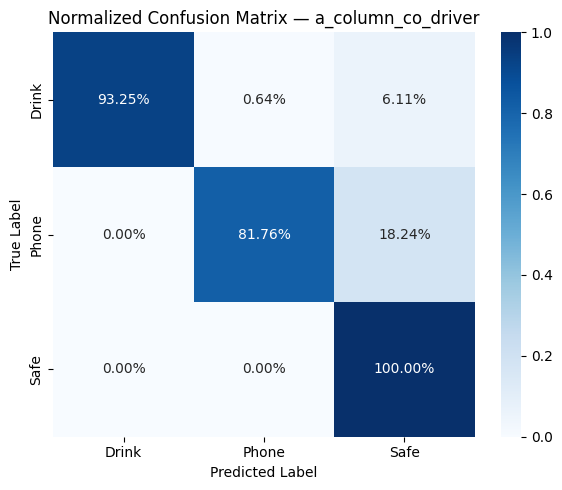

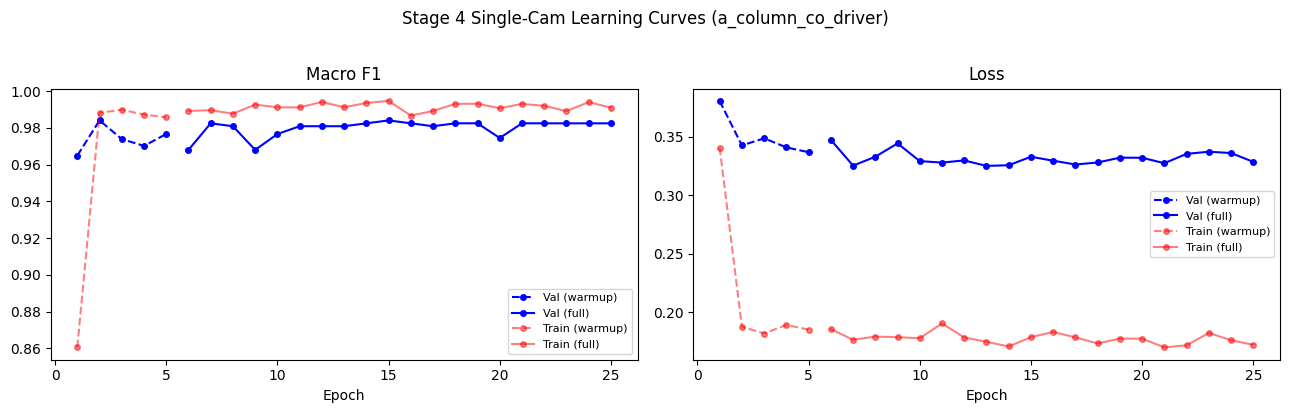

In [12]:
# Cell 11
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print('=' * 65)
print('TEST SET EVALUATION')
print('=' * 65)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Test'):
        x = x.to(device)
        with autocast():
            logits = model(x)
        all_preds.extend(logits.float().argmax(dim=1).cpu().tolist())
        all_labels.extend(y.tolist())

print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=CFG['classes']))

cm = confusion_matrix(all_labels, all_preds, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CFG['classes'], yticklabels=CFG['classes'], ax=ax)
ax.set_xlabel('Predicted Label');  ax.set_ylabel('True Label')
ax.set_title(f'Normalized Confusion Matrix — {CFG["camera"]}')
plt.tight_layout()
plt.show()

n_warm = len(warmup_history['val_f1'])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (val_key, train_key, title) in zip(axes, [
    ('val_f1',   'train_f1',   'Macro F1'),
    ('val_loss', 'train_loss', 'Loss'),
]):
    xs_w = list(range(1, n_warm + 1))
    xs_f = list(range(n_warm + 1, n_warm + len(full_history[val_key]) + 1))
    ax.plot(xs_w, warmup_history[val_key],   'b--o', ms=4, label='Val (warmup)')
    ax.plot(xs_f, full_history[val_key],     'b-o',  ms=4, label='Val (full)')
    ax.plot(xs_w, warmup_history[train_key], 'r--o', ms=4, alpha=0.5, label='Train (warmup)')
    ax.plot(xs_f, full_history[train_key],   'r-o',  ms=4, alpha=0.5, label='Train (full)')
    ax.set_title(title);  ax.legend(fontsize=8);  ax.set_xlabel('Epoch')
plt.suptitle(f'Stage 4 Single-Cam Learning Curves ({CFG["camera"]})', y=1.02)
plt.tight_layout()
plt.show()


In [13]:
# Cell 12
local_model_name = CFG['checkpoint_name']
drive_save_path  = '/content/drive/MyDrive/DriveGuard/models'
destination      = os.path.join(drive_save_path, local_model_name)

if os.path.exists(local_model_name):
    size_mb = os.path.getsize(local_model_name) / (1024 * 1024)
    print(f"Local model size (Colab): {size_mb:.2f} MB")
else:
    print(f"Local file {local_model_name} not found.")

if os.path.exists(destination):
    drive_size_mb = os.path.getsize(destination) / (1024 * 1024)
    print(f"Model already exists in Drive: {drive_size_mb:.2f} MB")
else:
    print("No backup found in Google Drive yet.")

os.makedirs(drive_save_path, exist_ok=True)

if os.path.exists(local_model_name):
    shutil.copy(local_model_name, destination)
    print(f"SUCCESS: Model saved to Drive: {destination}")
    print(f"Best val macro F1: {best_f1:.4f}")
else:
    print("ERROR: Copy failed, local model file not found.")


Local model size (Colab): 87.60 MB
Model already exists in Drive: 50.42 MB
SUCCESS: Model saved to Drive: /content/drive/MyDrive/DriveGuard/models/temporal_head_model.pth
Best val macro F1: 0.9840


In [14]:
# Cell 13
from collections import defaultdict

model.eval()
failures = []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Scanning'):
        x = x.to(device)
        with autocast():
            logits = model(x)
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1).cpu()
        conf  = probs.max(dim=1).values.cpu()
        y_cpu = y.cpu()
        for i in (preds != y_cpu).nonzero(as_tuple=True)[0]:
            failures.append({
                'true': CFG['classes'][y_cpu[i].item()],
                'pred': CFG['classes'][preds[i].item()],
                'conf': conf[i].item(),
            })

failures.sort(key=lambda r: -r['conf'])
error_rate = 100 * len(failures) / max(len(test_ds), 1)
print(f'Hard Failures: {len(failures)} / {len(test_ds)}  ({error_rate:.1f}% error rate)')
print(f'\n{"True":8s}  {"Pred":8s}  {"Conf":>8s}')
print('-' * 28)
for r in failures[:15]:
    print(f'{r["true"]:8s}  {r["pred"]:8s}  {r["conf"]:8.4f}')

pairs = defaultdict(int)
for r in failures:
    pairs[(r['true'], r['pred'])] += 1
print('\nConfusion pairs (true -> pred : count):')
for (t, p), c in sorted(pairs.items(), key=lambda x: -x[1]):
    print(f'  {t} -> {p} : {c}')


Scanning:   0%|          | 0/25 [00:00<?, ?it/s]

Hard Failures: 48 / 782  (6.1% error rate)

True      Pred          Conf
----------------------------
Phone     Safe        0.9691
Phone     Safe        0.9669
Phone     Safe        0.9546
Phone     Safe        0.9542
Phone     Safe        0.9530
Phone     Safe        0.9521
Phone     Safe        0.9498
Phone     Safe        0.9483
Phone     Safe        0.9458
Drink     Safe        0.9385
Phone     Safe        0.9329
Phone     Safe        0.9326
Drink     Safe        0.9215
Phone     Safe        0.9134
Phone     Safe        0.9131

Confusion pairs (true -> pred : count):
  Phone -> Safe : 27
  Drink -> Safe : 19
  Drink -> Phone : 2
